Now, we will look at memory for activation values (saved for computing gradients in back propagation).

We can empirically test how much activation memory is needed as the sequences get longer and longer.

We can empirically test this value by doing a forward pass, and during the forward pass store the activation values and seeing how much memory they take

In [1]:
import torch
import matplotlib.pyplot as plt
import mini_gpt

config = mini_gpt.ModelConfig()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cpu":
    print("Warning: CUDA not available. Memory measurement won't work properly.")


seq_lengths = [256, 512, 1024, 2048, 4096, 8192]

In [2]:
def test_memory(seq_lengths, config, device, recompute):

    measured_mb = []

    for sl in seq_lengths:

        if recompute:
          m = MiniTransformerCheckpoint(config).to(device)
        else:
          m = mini_gpt.MiniTransformer(config).to(device)

        if device.type == "cuda":
            torch.cuda.reset_peak_memory_stats(device)
            torch.cuda.empty_cache()

        x = torch.randint(0, config.vocab_size, (1, sl)).to(device)
        logits = m(x)

        peak_mem = torch.cuda.max_memory_allocated(device)

        mb = peak_mem / 1e6
        measured_mb.append(mb)
        print(f"seq={sl}: {mb:.2f} MB (peak)")

    return measured_mb

In [5]:
measured_mb = test_memory(seq_lengths, config, device, recompute=False)

seq=256: 43.65 MB (peak)
seq=512: 108.05 MB (peak)
seq=1024: 220.84 MB (peak)
seq=2048: 599.08 MB (peak)
seq=4096: 1958.23 MB (peak)
seq=8192: 7095.40 MB (peak)


Note, since we measured the peak memory during a run with a certain sequnce length, this actually includes memory of the parameters, gradients, and optimizers.

Still, you can visually tell how memory grows as sequence length grows.

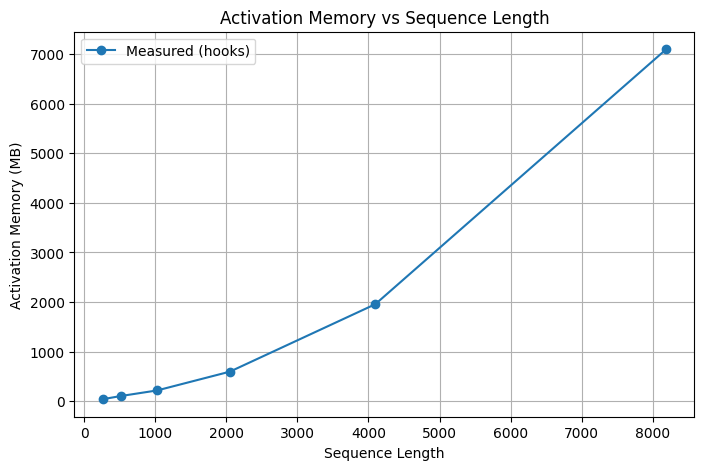

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(seq_lengths, measured_mb, 'o-', label='Measured (hooks)')
plt.xlabel('Sequence Length')
plt.ylabel('Activation Memory (MB)')
plt.title('Activation Memory vs Sequence Length')
plt.grid(True)
plt.legend()
plt.show()

This obviously sucks, as sequence length gets longer, memory exponentially grows, is there some way that we can use recomputation to solve this issue?

We won't do a full recompute, the idea is we set certain checkpoints for recomputation in the backward pass, I love how checkpoints are built into Pytorch by default.

In [10]:
from torch.utils.checkpoint import checkpoint


class MiniTransformerCheckpoint(mini_gpt.MiniTransformer):

    def __init__(self, config, checkpoint_interval=2):
        super().__init__(config)
        self.checkpoint_interval = checkpoint_interval

    def forward(self, input_ids):
        h = self.embedding(input_ids)

        for i, layer in enumerate(self.layers):
            if (i + 1) % self.checkpoint_interval == 0:
                h = checkpoint(layer, h, use_reentrant=False)
            else:
                h = layer(h)

        h = self.final_norm(h)
        return self.lm_head(h)

In [11]:
measured_mb_with_recompute = test_memory(seq_lengths, config, device, recompute=True)

seq=256: 36.85 MB (peak)
seq=512: 85.48 MB (peak)
seq=1024: 169.42 MB (peak)
seq=2048: 445.92 MB (peak)
seq=4096: 1453.73 MB (peak)
seq=8192: 5282.34 MB (peak)


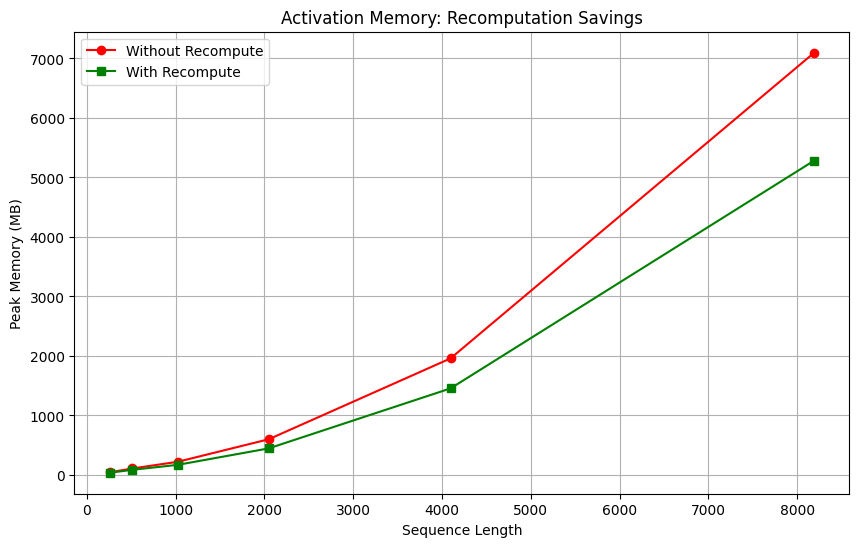


Memory Savings:
seq=256: 6.80 MB saved (15.6% reduction)
seq=512: 22.57 MB saved (20.9% reduction)
seq=1024: 51.42 MB saved (23.3% reduction)
seq=2048: 153.16 MB saved (25.6% reduction)
seq=4096: 504.50 MB saved (25.8% reduction)
seq=8192: 1813.05 MB saved (25.6% reduction)


In [12]:
# Compare memory usage: without vs with recomputation
plt.figure(figsize=(10, 6))
plt.plot(seq_lengths, measured_mb, 'o-', label='Without Recompute', color='red')
plt.plot(seq_lengths, measured_mb_with_recompute, 's-', label='With Recompute', color='green')
plt.xlabel('Sequence Length')
plt.ylabel('Peak Memory (MB)')
plt.title('Activation Memory: Recomputation Savings')
plt.grid(True)
plt.legend()
plt.show()

# Print savings
print("\nMemory Savings:")
for sl, mb_old, mb_new in zip(seq_lengths, measured_mb, measured_mb_with_recompute):
    savings = mb_old - mb_new
    pct = (savings / mb_old) * 100
    print(f"seq={sl}: {savings:.2f} MB saved ({pct:.1f}% reduction)")

It's a really small model... so don't expect much improvement directly.